# Day 0：环境配置与测试

**请在培训开始前完成本 notebook 的所有步骤。**

本 notebook 将帮助你：
1. 安装所有必要的 Python 依赖
2. 申请并配置阿里百炼 (DashScope) API Key
3. 验证 LLM 和 Embedding 后端是否正常工作
4. 确认字体、数据文件等资源完整

---

## 目录

| 步骤 | 内容 | 预计时间 |
|:---:|------|:---:|
| 1 | Python 环境检查 | 2 min |
| 2 | 安装依赖包 | 5 min |
| 3 | 申请阿里百炼 API Key | 5 min |
| 4 | 配置 API Key | 1 min |
| 5 | 测试 LLM 后端 | 1 min |
| 6 | 测试 Embedding 后端 | 1 min |
| 7 | 检查其他依赖 | 1 min |
| 8 | 全部通过！ | - |

> 📋 **讲课提示** *(此区块仅讲师版含，学员版自动剥离)*
> 
> **本节：** Day 0 · 环境配置（开班前自助 20 min）　|　**时长：** 20 min
> 
> **开场：** 开课前发出来让学员自己跑通即可。开课当天前 5 分钟现场抽查 1-2 位学员的 Step 5 LLM 测试 ✅。
> 
> **重点强调：**
> - **conda activate llmcs** —— 强调使用统一的 conda 环境，避免依赖打架
> - API Key 不要提交 git；推荐永久配环境变量（Step 4 末尾）
> - 字体路径使用相对路径自动定位（学员从 instructor/ 或 student/ 都能跑）
>
> **常见误解：**
> - 学员经常以为 `pip install` 在 base 环境就行 → 强调先 `conda activate llmcs`
> - 学员看到 ⚠️ GPU 不可用就放弃 → 强调 Day 1-2 大部分内容 CPU 也能跑
>
> **互动设计：** Step 5 跑通后，让学员把 LLM 回的第一句『自我介绍』贴在群里，即可作为签到。
>
> **时间紧时：** 若开课前未发，直接 5 分钟讲师演示一遍 Step 1→Step 7，告诉学员后续课中再补。

In [1]:
# ── 课程环境就位（自动定位课程根目录，让 utils/data/fonts 路径无论从 instructor/ 还是 student/ 都能用）──
import os, sys
_cur = os.path.abspath("")
_root = None
for _candidate in [_cur] + [os.path.dirname(_cur), os.path.dirname(os.path.dirname(_cur))]:
    if all(os.path.isdir(os.path.join(_candidate, d)) for d in ("utils", "data")):
        _root = _candidate
        break
if _root is None:
    raise RuntimeError("找不到课程根目录（应包含 utils/ 与 data/）。请确认 notebook 位于 enterprise_ver2/instructor 或 enterprise_ver2/student 下。")
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
if os.path.join(_root, "utils") not in sys.path:
    sys.path.insert(0, os.path.join(_root, "utils"))
print(f"📂 课程根目录：{_root}")


📂 课程根目录：C:\Users\lvbab\Documents\GitHub\LLM-Agent-Core_Concept_Code\assets\enterprise_ver2


---
## Step 1：Python 环境检查

要求：**Python 3.10+**（推荐使用 `llmcs` 环境：Python 3.11.15）

In [2]:
import sys
print(f"Python 版本: {sys.version}")
assert sys.version_info >= (3, 10), "需要 Python 3.10+，请升级或切换到 llmcs 环境！"
print("✅ Python 版本符合要求")

Python 版本: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
✅ Python 版本符合要求


---
## Step 1.5：确认 conda 环境

本课程统一推荐使用 conda 环境 `llmcs`（已配 PyTorch / transformers / peft / dashscope / sentence-transformers）。

如果你还没建过：
```bash
conda create -n llmcs python=3.11 -y
conda activate llmcs
pip install -r requirements.txt
```

**确认 Jupyter 用的是 llmcs 内核：** Kernel 菜单 → Change Kernel → 选 `Python (llmcs)`。

运行下面的 cell 自检：

In [3]:
import sys, platform
print(f"Python 解释器：{sys.executable}")
print(f"Python 版本：{platform.python_version()}")
is_isolated = "envs" in sys.executable or "llmcs" in sys.executable.lower()
if is_isolated:
    print("✅ 看起来在 conda 隔离环境里（推荐 llmcs）")
else:
    print("⚠️ 似乎在系统 Python 里跑。建议 `conda activate llmcs` 后重启 Jupyter。")
    print("   不切环境也能跑，但容易遇到依赖版本冲突。")


Python 解释器：E:\conda\envs\llmcs\python.exe
Python 版本：3.11.15
✅ 看起来在 conda 隔离环境里（推荐 llmcs）


---
## Step 2：安装依赖包

运行下面的 cell 安装所有必要的 Python 包。如果某个包已安装，会自动跳过。

> **注意：** PyTorch 建议根据你的环境单独安装：
> - **有 NVIDIA GPU：** 去 [pytorch.org](https://pytorch.org/get-started/locally/) 选择对应 CUDA 版本
> - **无 GPU / Mac：** `pip install torch` 即可（CPU 版本可完成大部分内容）

In [4]:
# 依赖安装建议在终端完成，避免 notebook 执行时覆盖已验证的 llmcs 环境。
#
# 推荐命令：
#   conda activate llmcs
#   pip install -r requirements.txt
#
# 如课堂现场确实需要在 notebook 内安装，把 RUN_INSTALL 改成 True。
RUN_INSTALL = False

if RUN_INSTALL:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
else:
    print("跳过自动安装；当前 notebook 使用已配置好的 llmcs kernel。")
    print("如缺依赖，请先在终端运行：conda activate llmcs && pip install -r requirements.txt")


跳过自动安装；当前 notebook 使用已配置好的 llmcs kernel。
如缺依赖，请先在终端运行：conda activate llmcs && pip install -r requirements.txt


In [5]:
# 检查所有关键包是否安装成功
packages = {
    "torch": "PyTorch（深度学习框架）",
    "numpy": "NumPy（数值计算）",
    "matplotlib": "Matplotlib（绘图）",
    "sklearn": "Scikit-learn（机器学习工具）",
    "openai": "OpenAI SDK（DashScope 兼容接口）",
    "tiktoken": "Tiktoken（Tokenizer）",
    "transformers": "Transformers（HuggingFace 模型库）",
    "peft": "PEFT（LoRA 微调）",
    "trl": "TRL（SFT/DPO 训练）",
    "datasets": "Datasets（数据加载）",
}

all_ok = True
for pkg, desc in packages.items():
    try:
        __import__(pkg)
        print(f"  ✅ {desc}")
    except ImportError:
        print(f"  ❌ {desc} — 未安装！请运行: pip install {pkg}")
        all_ok = False

# sentence-transformers 特殊处理
try:
    import sentence_transformers
    print(f"  ✅ Sentence-Transformers（本地 Embedding 备选）")
except ImportError:
    print(f"  ⚠️ Sentence-Transformers 未安装（可选，DashScope 可替代）")

if all_ok:
    print("\n✅ 所有核心包已就绪！")
else:
    print("\n⚠️ 部分包缺失，请根据上方提示安装")

  ✅ PyTorch（深度学习框架）
  ✅ NumPy（数值计算）
  ✅ Matplotlib（绘图）


  ✅ Scikit-learn（机器学习工具）


  ✅ OpenAI SDK（DashScope 兼容接口）
  ✅ Tiktoken（Tokenizer）


  ✅ Transformers（HuggingFace 模型库）


  ✅ PEFT（LoRA 微调）


  ✅ TRL（SFT/DPO 训练）


  ✅ Datasets（数据加载）


  ✅ Sentence-Transformers（本地 Embedding 备选）

✅ 所有核心包已就绪！


---
## Step 3：申请阿里百炼 (DashScope) API Key

本课程统一使用**阿里百炼 (DashScope)** 作为 LLM 和 Embedding 后端。它提供通义千问系列模型的 API 访问，兼容 OpenAI 接口格式。

### 申请步骤

**1. 注册阿里云账号**

前往 [阿里云官网](https://www.aliyun.com/) 注册账号（如已有账号可跳过）。

**2. 开通百炼服务**

前往 [百炼控制台](https://dashscope.console.aliyun.com/)，点击"开通服务"。

**3. 创建 API Key**

进入控制台后：
- 点击左侧菜单 **「API-KEY 管理」**
- 点击 **「创建新的 API-KEY」**
- 复制生成的 Key（格式通常以 `sk-` 开头）

> **重要提示：**
> - API Key 只会显示一次，请妥善保存
> - 新用户通常有**免费额度**，足够完成本课程所有练习
> - 不要将 API Key 提交到 Git 或分享给他人

### 使用的模型

| 用途 | 模型名称 | 说明 |
|------|---------|------|
| LLM 对话 | `qwen-plus` | 通义千问，性价比最高（推荐） |
| LLM 快速 | `qwen-turbo` | 更快更便宜，适合简单任务 |
| LLM 最强 | `qwen-max` | 最强能力，价格较高 |
| Embedding | `text-embedding-v3` | 文本向量化，1024 维 |

---
## Step 4：配置 API Key 和模型选择

填入 API Key，选择要使用的模型，运行后会自动保存到 `.env` 文件。**后续所有 notebook 会自动读取这个配置，不用重复填写。**

In [6]:
import os, sys

# ============================================================
# 只需要改这一行：把 DashScope / 阿里百炼控制台复制的完整 key 粘贴进来
# 如果你已经把 DASHSCOPE_API_KEY 配成系统环境变量，这里可以留空。
# ============================================================
DASHSCOPE_API_KEY = ""  # 示例: "<your_api_key>xxxxx"，不要把真实 key 发到群里或提交到 Git
# ============================================================

# Model selection: fixed snapshot by default; switch to qwen-turbo for faster/cheaper, or qwen-plus for latest alias.
LLM_MODEL = "qwen-plus-2025-01-25"
EMBEDDING_MODEL = "text-embedding-v3"

from config import save_config

api_key = DASHSCOPE_API_KEY.strip() or os.getenv("DASHSCOPE_API_KEY", "").strip()

if api_key.startswith("sk-") and len(api_key) > 10:
    save_config(
        api_key=api_key,
        llm_backend="dashscope",
        llm_model=LLM_MODEL,
        embedding_backend="dashscope",
        embedding_model=EMBEDDING_MODEL,
    )
    print()
    print("📋 当前配置：")
    print("  API Key:   ✓ 已配置（已隐藏）")
    print(f"  LLM:       dashscope / {LLM_MODEL}")
    print(f"  Embedding: dashscope / {EMBEDDING_MODEL}")
else:
    print("❌ 还没有检测到可用的 DashScope API Key")
    print('   只需要改上面的 DASHSCOPE_API_KEY = "..." 这一行')
    print("   Key 应以 sk- 开头；申请地址: https://dashscope.console.aliyun.com/")


✅ 配置已保存到: C:\Users\lvbab\Documents\GitHub\LLM-Agent-Core_Concept_Code\assets\enterprise_ver2\.env

📋 当前配置：
  API Key:   ✓ 已配置（已隐藏）
  LLM:       dashscope / qwen-plus-2025-01-25
  Embedding: dashscope / text-embedding-v3


### 方式二（推荐）：永久配置环境变量

如果你不想每次打开 notebook 都填写 Key，可以将其设为系统环境变量：

**Windows (PowerShell):**
```powershell
[Environment]::SetEnvironmentVariable("DASHSCOPE_API_KEY", "sk-你的key", "User")
```

**Windows (CMD):**
```cmd
setx DASHSCOPE_API_KEY "sk-你的key"
```

**Mac / Linux:**
```bash
echo 'export DASHSCOPE_API_KEY="sk-你的key"' >> ~/.bashrc
source ~/.bashrc
```

设置后重启 Jupyter，Key 会自动生效，不需要在 notebook 里手动填写。

---
## Step 5：测试 LLM 后端

使用通义千问 (qwen-plus) 进行一次简单对话测试。

In [7]:
from config import setup

# 加载配置（读取 Step 4 保存的 .env 文件）
env = setup()

# 测试 LLM
try:
    llm = env.get_llm()
    response = llm.chat([{"role": "user", "content": "用一句话介绍你自己"}])
    print(f"\n✅ LLM 测试成功！")
    print(f"回复: {response.strip()}")
except Exception as e:
    print(f"❌ LLM 测试失败: {e}")
    print("\n请检查：")
    print("  1. API Key 是否正确填写？（回到 Step 4）")
    print("  2. 网络是否能访问 dashscope.aliyuncs.com？")
    print("  3. 百炼服务是否已开通？")

[OK] 已加载配置: C:\Users\lvbab\Documents\GitHub\LLM-Agent-Core_Concept_Code\assets\enterprise_ver2\.env
课程环境配置:
  API Key:   ✓ 已配置
  LLM:       dashscope / qwen-plus-2025-01-25
  Embedding: dashscope / text-embedding-v3


[LLM] dashscope / qwen-plus-2025-01-25



✅ LLM 测试成功！
回复: 我是通义千问，阿里巴巴集团旗下的超大规模语言模型，能够帮助你回答问题、创作文字、编程等。


---
## Step 6：测试 Embedding 后端

Embedding 用于将文本转换为向量，是 Day 3 RAG 系统的核心组件。

In [8]:
import numpy as np

# 使用上一步加载的 env（如果直接运行本 cell，会重新加载）
try:
    env
except NameError:
    from config import setup
    env = setup()

# 测试 Embedding
try:
    embedder = env.get_embedder()
    
    # 测试向量化
    sentences = ["机器学习很有趣", "深度学习是AI的核心", "今天天气不错"]
    vectors = embedder.embed(sentences)
    
    print(f"\n✅ Embedding 测试成功！")
    print(f"向量维度: {vectors.shape[1]}")
    print(f"测试句子数: {len(sentences)}")
    
    # 简单相似度演示
    sim_12 = np.dot(vectors[0], vectors[1])
    sim_13 = np.dot(vectors[0], vectors[2])
    print(f"\n语义相似度演示:")
    print(f"  '{sentences[0]}' vs '{sentences[1]}': {sim_12:.4f} (相关)")
    print(f"  '{sentences[0]}' vs '{sentences[2]}': {sim_13:.4f} (不太相关)")
    
except Exception as e:
    print(f"❌ Embedding 测试失败: {e}")
    print("\n请检查 API Key 是否正确配置（回到 Step 4）")

[Embedding] dashscope / text-embedding-v3 (dim=1024)



✅ Embedding 测试成功！
向量维度: 1024
测试句子数: 3

语义相似度演示:
  '机器学习很有趣' vs '深度学习是AI的核心': 0.5718 (相关)
  '机器学习很有趣' vs '今天天气不错': 0.5411 (不太相关)


---
## Step 7：检查其他依赖

验证 PyTorch、字体文件、数据文件等是否就绪。

环境全面检查

1. PyTorch: ✅ 2.11.0+cu128  |  ✅ CUDA 可用
2. 中文字体: ✅ fonts\NotoSansCJKsc-Regular.otf
3. 训练数据: ✅ data\custom_pretrain_corpus.txt
4. 预训练模型: ✅ models\ch7_pretrain_best_model.pt
5. llm_backend.py: ✅
5. embedding_backend.py: ✅


C:\Users\lvbab\AppData\Local\Temp\ipykernel_319748\244419944.py:55: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
E:\conda\envs\llmcs\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


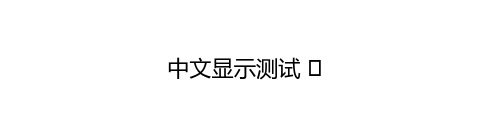

6. Matplotlib 中文: ✅（如上图显示正常即可）


In [9]:
import os

print("=" * 50)
print("环境全面检查")
print("=" * 50)

# 1. PyTorch
try:
    import torch
    gpu = "✅ CUDA 可用" if torch.cuda.is_available() else "⚠️ 仅 CPU（大部分内容可完成）"
    print(f"\n1. PyTorch: ✅ {torch.__version__}  |  {gpu}")
except ImportError:
    print("\n1. PyTorch: ❌ 未安装！请运行: pip install torch")

# 2. 中文字体
font_path = os.path.join("fonts", "NotoSansCJKsc-Regular.otf")
if os.path.exists(font_path):
    print(f"2. 中文字体: ✅ {font_path}")
else:
    print(f"2. 中文字体: ⚠️ 未找到 {font_path}")
    print("   图表中文可能显示为方块，但不影响代码运行")

# 3. 数据文件
data_file = os.path.join("data", "custom_pretrain_corpus.txt")
if os.path.exists(data_file):
    print(f"3. 训练数据: ✅ {data_file}")
else:
    print(f"3. 训练数据: ⚠️ 未找到 {data_file}")

# 4. 预训练模型
model_file = os.path.join("models", "ch7_pretrain_best_model.pt")
if os.path.exists(model_file):
    print(f"4. 预训练模型: ✅ {model_file}")
else:
    print(f"4. 预训练模型: ⚠️ 未找到 {model_file}")

# 5. utils 模块
for mod in ["llm_backend.py", "embedding_backend.py"]:
    path = os.path.join("utils", mod)
    if os.path.exists(path):
        print(f"5. {mod}: ✅")
    else:
        print(f"5. {mod}: ❌ 未找到！请确认 utils/ 目录完整")

# 6. Matplotlib 中文测试
try:
    import matplotlib.pyplot as plt
    plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    fig, ax = plt.subplots(figsize=(5, 1.5))
    ax.text(0.5, 0.5, "中文显示测试 ✓", ha="center", va="center", fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    print("6. Matplotlib 中文: ✅（如上图显示正常即可）")
except Exception as e:
    print(f"6. Matplotlib 中文: ⚠️ {e}")

---
## Step 8：全部通过！

如果以上步骤都通过，环境配置完成。

### 课程文件结构

```
enterprise_ver2/                     # 课程根目录
├── instructor/                      # 讲师版（你现在在这里）
│   └── Day0~Day3_下午.ipynb
├── student/                         # 学员版（同 7 本，留填空）
├── .env                             # Step 4 自动生成（API Key + 模型配置）
├── utils/                           # 后端工具
│   ├── config.py                    # 统一配置（读取 .env）
│   ├── llm_backend.py               # LLM 后端
│   └── embedding_backend.py         # Embedding 后端
├── data/                            # 训练数据
└── models/                          # 预训练模型权重
fonts/                               # 中文字体（与 enterprise/ 同级）
└── NotoSansCJKsc-Regular.otf
```

### 配置如何在各 notebook 间共享？

Step 4 会将 API Key 和模型选择保存到 `.env` 文件。**后续所有 notebook 会自动读取这个文件**，不需要重复配置。

如果需要在某个 notebook 中使用 API（如 Day 3），开头会有这样的初始化代码：
```python
from config import setup
env = setup()           # 自动加载 .env 配置
llm = env.get_llm()     # 获取 LLM
embedder = env.get_embedder()  # 获取 Embedding
```

### 想换模型？

回到本 notebook 的 Step 4，修改 `LLM_MODEL` 或 `EMBEDDING_MODEL`，重新运行即可。

### 遇到问题？

| 问题 | 解决方案 |
|------|---------|
| `ModuleNotFoundError` | 重新运行 Step 2 的安装 cell |
| `DASHSCOPE_API_KEY` 错误 | 回到 Step 4 检查 Key 是否正确 |
| 网络超时 | 检查网络，确认能访问 dashscope.aliyuncs.com |
| 中文显示方块 | 确认 `fonts/` 目录下有字体文件 |
| GPU 相关错误 | Day 1-2 可用 CPU 完成，不影响学习 |]]>
